In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

In [37]:
df = pd.read_csv("../../data/raw/sentiment140_dataset.csv", encoding="latin-1", header=None)
df.columns = [
    "target",
    "id",
    "date",
    "flag",
    "user",
    "text"
]

# Word Count Per Tweet

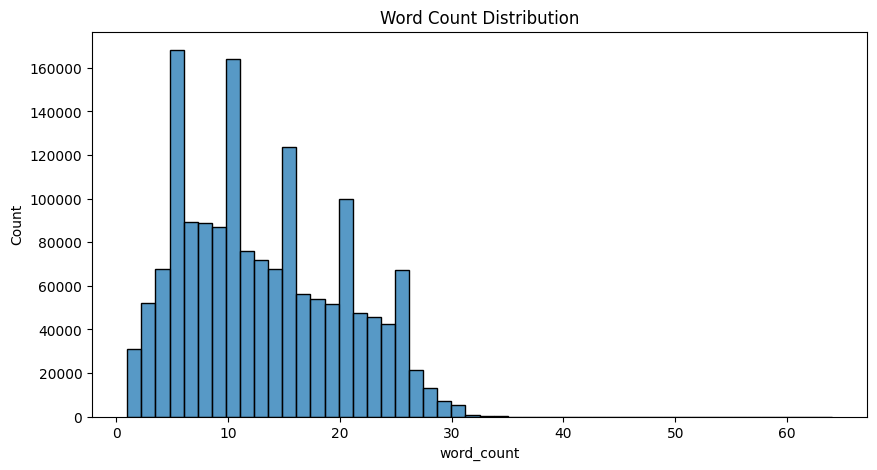

In [38]:
df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)
plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

Most Common Words

In [39]:
# Tokenize text
all_words = " ".join(
    df["text"].astype(str)
).lower().split()

# Remove stopwords
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
filtered_words = [
    word for word in all_words
    if word not in stop_words
]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Frequency distribution of words

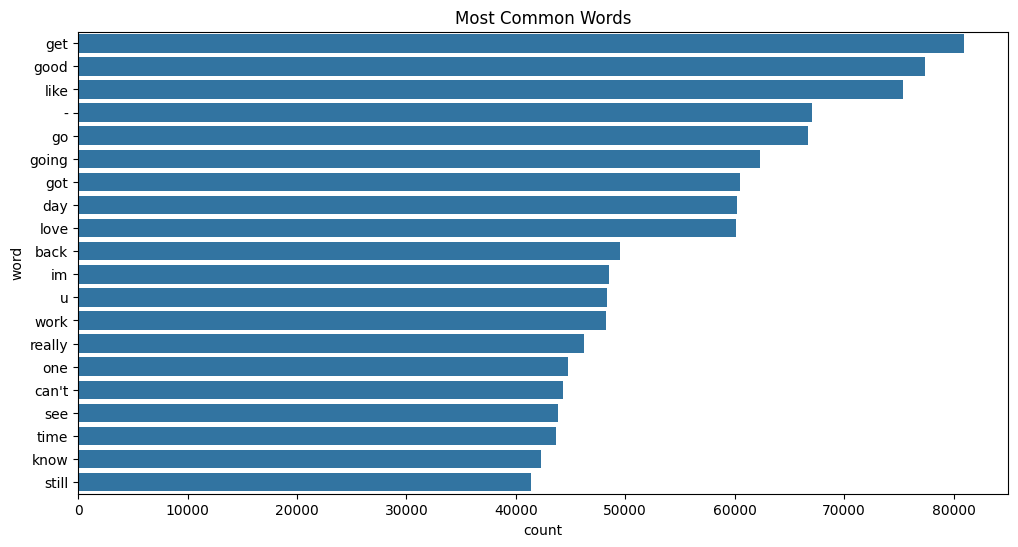

In [40]:
word_freq = Counter(filtered_words)
common_words = word_freq.most_common(20)

# Convert to DataFrame for visualization
freq_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=freq_df,
    x="count",
    y="word"
)

plt.title("Most Common Words")
plt.show()

Hashtag Analysis

<Axes: xlabel='hashtag_count', ylabel='Count'>

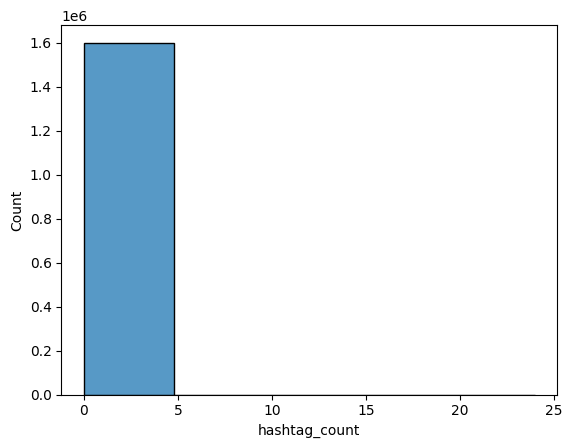

In [41]:
# Extract hashtags
df["hashtags"] = df["text"].apply(
    lambda x: re.findall(r"#(\w+)", str(x))
)

# Count hashtags
df["hashtag_count"] = df["hashtags"].apply(len)

# Visualize hashtag count distribution
sns.histplot(df["hashtag_count"], bins=5)

Mention Analysis

In [42]:
# Extract mentions
df["mentions"] = df["text"].apply(
    lambda x: re.findall(r"@(\w+)", str(x))
)

# Count mentions
df["mention_count"] = df["mentions"].apply(len)

URL Analysis

In [43]:
# Extract URLs
df["url_count"] = df["text"].apply(
    lambda x: len(
        re.findall(r"http\S+", str(x))
    )
)

Emoji Analysis

In [44]:
import emoji

def extract_emojis(text):
    return [
        c for c in str(text)
        if c in emoji.EMOJI_DATA
    ]

df["emojis"] = df["text"].apply(extract_emojis)

# Count emojis
df["emoji_count"] = df["emojis"].apply(len)

Punctiation Analysis

In [45]:
df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["ellipsis_count"] = df["text"].str.count(r"\.\.\.")

Capitalisation Analysis


In [46]:
def uppercase_ratio(text):
    text = str(text)

    if len(text) == 0:
        return 0

    upper = sum(1 for c in text if c.isupper())

    return upper / len(text)

df["uppercase_ratio"] = df["text"].apply(
    uppercase_ratio
)

Repeated Character Analysis

In [47]:
def repeated_characters(text):
    return len(
        re.findall(r"(.)\1{2,}", str(text))
    )

df["repeated_char_count"] = df["text"].apply(
    repeated_characters
)

Bigram Extraction

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["text"].astype(str)
)

Word Clouds

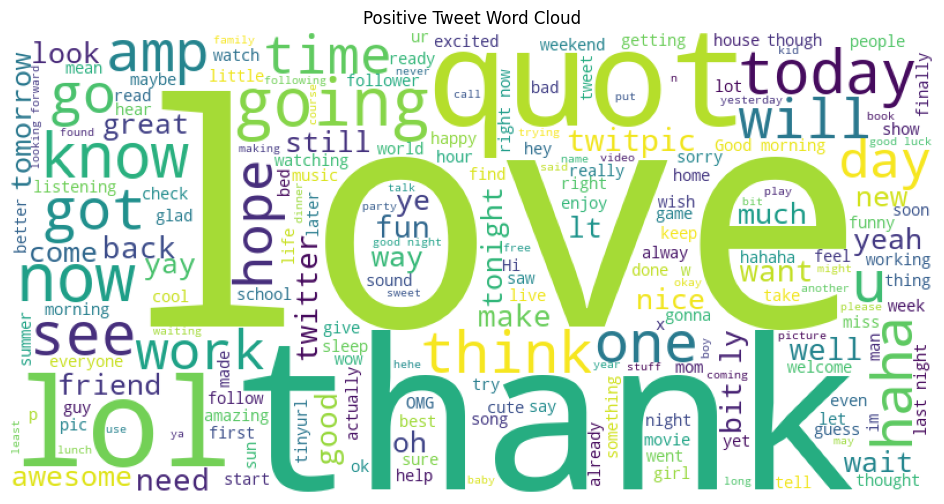

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
    df[df["target"] == 4]["text"].astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweet Word Cloud")

plt.show()

Correlation Analysis

<Axes: >

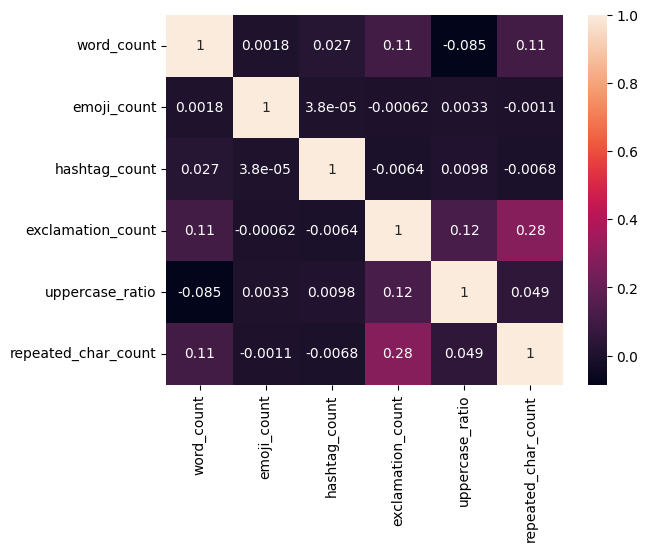

In [50]:
feature_columns = [
    "word_count",
    "emoji_count",
    "hashtag_count",
    "exclamation_count",
    "uppercase_ratio",
    "repeated_char_count"
]

df[feature_columns].corr()

sns.heatmap(
    df[feature_columns].corr(),
    annot=True
)